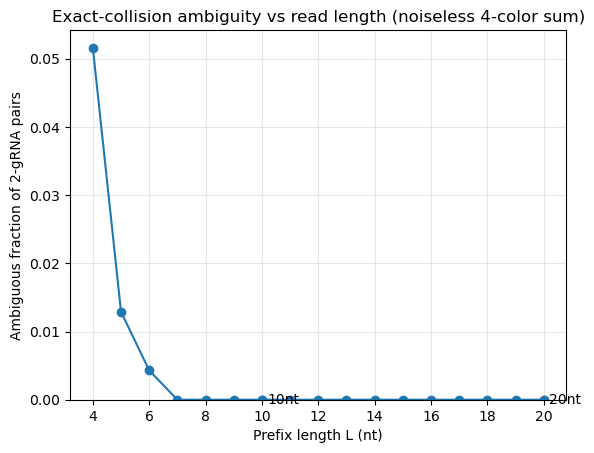

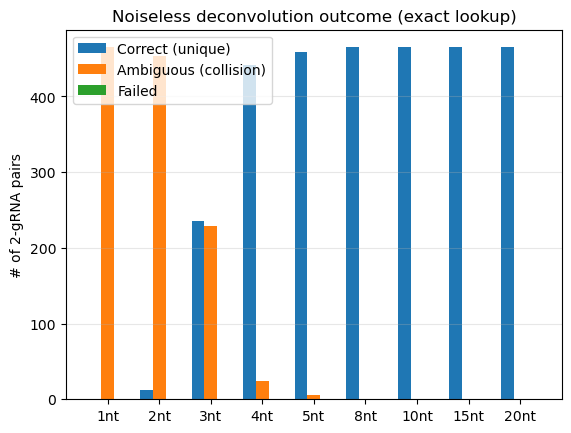

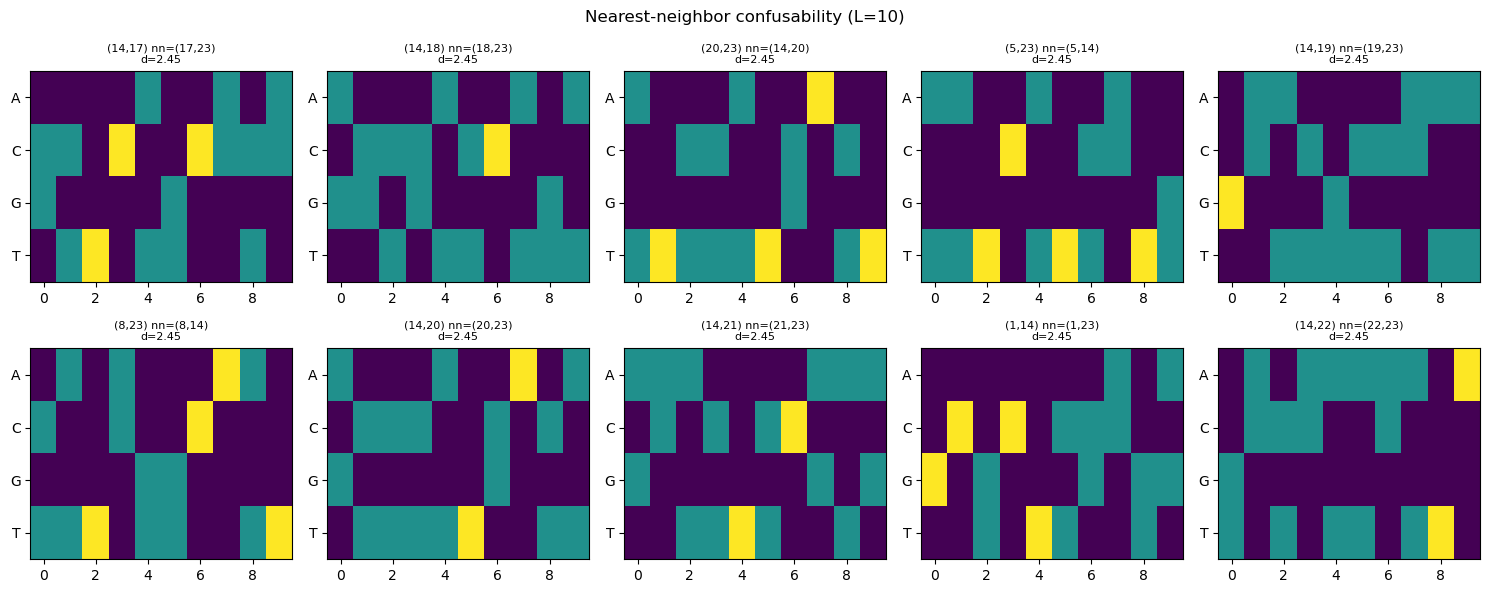

In [2]:
# Succinct, from-scratch, deterministic collision + deconvolution analysis
# Assumptions:
# - 4-color chemistry: A,C,G,T channels
# - "Not spatially resolvable" => signals ADD (pair sum)
# - Unordered pairs with replacement (i<=j)
# - No noise

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement

BASES = "ACGT"
B2I = {b:i for i,b in enumerate(BASES)}

def onehot_4color(seq: str, L: int) -> np.ndarray:
    """(L,4) one-hot encoding for first L bases of seq."""
    x = np.zeros((L, 4), dtype=np.uint8)
    for p, b in enumerate(seq[:L]):
        x[p, B2I[b]] = 1
    return x

def pair_sum(seq1: str, seq2: str, L: int) -> np.ndarray:
    """(L,4) summed 4-color signal for two spacers."""
    return onehot_4color(seq1, L).astype(np.int16) + onehot_4color(seq2, L).astype(np.int16)

def all_pairs(n: int):
    return list(combinations_with_replacement(range(n), 2))

def signal_key(sig: np.ndarray):
    """Hashable key for exact collision detection."""
    return tuple(sig.reshape(-1).tolist())

def collision_stats(spacers, L: int):
    """Exact collisions: signals that map to >1 pair."""
    pairs = all_pairs(len(spacers))
    m = {}
    for (i, j) in pairs:
        k = signal_key(pair_sum(spacers[i], spacers[j], L))
        m.setdefault(k, []).append((i, j))
    total_pairs = len(pairs)
    unique_signals = len(m)
    collision_groups = {k:v for k,v in m.items() if len(v) > 1}
    ambiguous_pairs = sum(len(v) for v in collision_groups.values())
    return {
        "L": L,
        "total_pairs": total_pairs,
        "unique_signals": unique_signals,
        "ambiguous_pairs": ambiguous_pairs,
        "ambiguous_fraction": ambiguous_pairs / total_pairs,
        "n_collision_groups": len(collision_groups),
        "max_group_size": (max((len(v) for v in collision_groups.values()), default=1)),
        "collision_groups": collision_groups,   # key -> list[(i,j)]
        "mapping": m,                           # full mapping key -> list[(i,j)]
    }

def deconvolution_counts(spacers, L: int):
    """
    Deterministic deconvolution using exact lookup:
    - correct: observed signal maps uniquely to the true pair
    - ambiguous: observed signal maps to >1 pair (collision)
    - failed: should be 0 here (lookup always contains the signal)
    """
    stats = collision_stats(spacers, L)
    m = stats["mapping"]
    pairs = all_pairs(len(spacers))
    correct = ambiguous = failed = 0
    for (i, j) in pairs:
        k = signal_key(pair_sum(spacers[i], spacers[j], L))
        cand = m.get(k, [])
        if len(cand) == 0:
            failed += 1
        elif len(cand) == 1 and cand[0] == (i, j):
            correct += 1
        else:
            # could still contain (i,j), but ambiguous in principle
            ambiguous += 1
    return {"L": L, "correct": correct, "ambiguous": ambiguous, "failed": failed, "total": len(pairs)}

# ---------- FIGURE 1: ambiguity vs prefix length ----------
def plot_ambiguity_vs_L(spacers, Ls=range(4, 21), mark=(10, 20)):
    amb = []
    for L in Ls:
        amb.append(collision_stats(spacers, L)["ambiguous_fraction"])
    plt.figure()
    plt.plot(list(Ls), amb, marker="o")
    plt.xlabel("Prefix length L (nt)")
    plt.ylabel("Ambiguous fraction of 2-gRNA pairs")
    plt.title("Exact-collision ambiguity vs read length (noiseless 4-color sum)")
    for Lm in mark:
        if Lm in Ls:
            idx = list(Ls).index(Lm)
            plt.scatter([Lm], [amb[idx]])
            plt.text(Lm + 0.2, amb[idx], f"{Lm}nt", va="center")
    plt.ylim(bottom=0)
    plt.grid(True, alpha=0.3)
    plt.show()

# ---------- FIGURE 3: noiseless deconvolution outcome (10 vs 20) ----------
def plot_deconvolution_bars(spacers, Ls=(10, 20)):
    cats = ["correct", "ambiguous", "failed"]
    vals = []
    for L in Ls:
        res = deconvolution_counts(spacers, L)
        vals.append([res[c] for c in cats])

    x = np.arange(len(Ls))
    w = 0.25
    plt.figure()
    plt.bar(x - w, [v[0] for v in vals], w, label="Correct (unique)")
    plt.bar(x,      [v[1] for v in vals], w, label="Ambiguous (collision)")
    plt.bar(x + w,  [v[2] for v in vals], w, label="Failed")
    plt.xticks(x, [f"{L}nt" for L in Ls])
    plt.ylabel("# of 2-gRNA pairs")
    plt.title("Noiseless deconvolution outcome (exact lookup)")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.show()

# ---------- OPTIONAL: “risk” view (nearest-neighbor distance) ----------
def plot_nearest_neighbor_risk(spacers, L=10, n_show=10):
    pairs = all_pairs(len(spacers))
    X = np.stack([pair_sum(spacers[i], spacers[j], L).reshape(-1) for (i, j) in pairs]).astype(float)
    # compute nearest-neighbor distance for each row (O(N^2) but N=465 for 30 spacers)
    dmin = np.full(len(pairs), np.inf)
    nn = np.full(len(pairs), -1, dtype=int)
    for a in range(len(pairs)):
        diffs = X - X[a]
        dist = np.linalg.norm(diffs, axis=1)
        dist[a] = np.inf
        b = int(dist.argmin())
        dmin[a] = dist[b]
        nn[a] = b

    riskiest = np.argsort(dmin)[:n_show]
    cols = 5
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axes = np.array(axes).reshape(-1)

    for k, idx in enumerate(riskiest):
        i, j = pairs[idx]
        bi, bj = pairs[nn[idx]]
        sig = pair_sum(spacers[i], spacers[j], L)
        axes[k].imshow(sig.T, aspect="auto", vmin=0, vmax=2)
        axes[k].set_yticks([0,1,2,3])
        axes[k].set_yticklabels(list(BASES))
        axes[k].set_title(f"({i},{j}) nn=({bi},{bj})\nd={dmin[idx]:.2f}", fontsize=8)

    for k in range(n_show, len(axes)):
        axes[k].axis("off")

    plt.suptitle(f"Nearest-neighbor confusability (L={L})", fontsize=12)
    plt.tight_layout()
    plt.show()

# ================== USAGE ==================
# Provide spacers as a Python list of strings (A/C/G/T), e.g. first 30 from your dataset.
import pandas as pd
df = pd.read_csv("ops_cloning.csv")
spacers = df['Guide with handles'].str[20:].head(30).str.upper().tolist()
plot_ambiguity_vs_L(spacers, Ls=range(4,21), mark=(10,20))   # Figure 1
plot_deconvolution_bars(spacers, Ls=(1,2,3,4,5,8,10,15,20))                 # Figure 3
plot_nearest_neighbor_risk(spacers, L=10, n_show=10)         # Optional “risk” plot


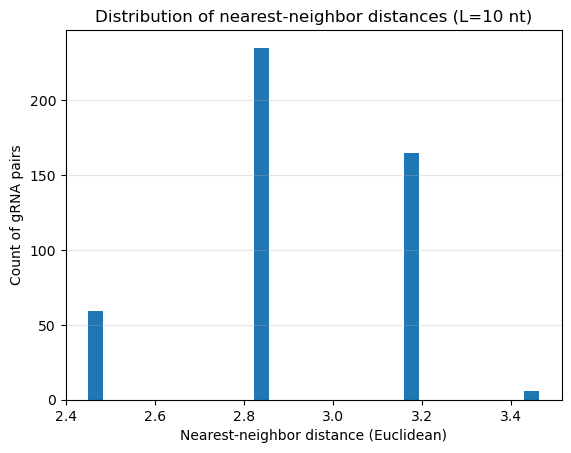

n pairs: 465
min/median/max: 2.449489742783178 2.8284271247461903 3.4641016151377544
Most common distances (rounded to 0.01):
  2.83: 235
  3.16: 165
  2.45: 59
  3.46: 6


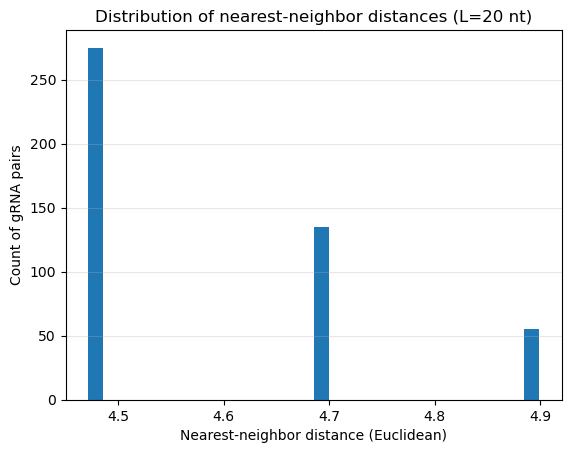

n pairs: 465
min/median/max: 4.47213595499958 4.47213595499958 4.898979485566356
Most common distances (rounded to 0.01):
  4.47: 275
  4.69: 135
  4.90: 55


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement
from scipy.spatial.distance import pdist, squareform

def plot_nn_distance_distribution(spacers, prefix_len=10, bins=30):
    # Build all unordered pairs (with replacement)
    pairs = list(combinations_with_replacement(range(len(spacers)), 2))

    # Build pair-sum signals and flatten
    X = np.stack(
        [pair_sum(spacers[i], spacers[j], prefix_len).reshape(-1) for (i, j) in pairs],
        axis=0
    ).astype(float)

    # Pairwise distances + nearest-neighbor distance for each pair-signal
    D = squareform(pdist(X, metric="euclidean"))
    np.fill_diagonal(D, np.inf)
    nn = D.min(axis=1)

    # Plot histogram
    plt.figure()
    plt.hist(nn, bins=bins)
    plt.xlabel("Nearest-neighbor distance (Euclidean)")
    plt.ylabel("Count of gRNA pairs")
    plt.title(f"Distribution of nearest-neighbor distances (L={prefix_len} nt)")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

    # Optional: print quick summary
    print("n pairs:", len(pairs))
    print("min/median/max:", float(nn.min()), float(np.median(nn)), float(nn.max()))
    vals, counts = np.unique(np.round(nn, 2), return_counts=True)
    top = np.argsort(counts)[::-1][:10]
    print("Most common distances (rounded to 0.01):")
    for v, c in zip(vals[top], counts[top]):
        print(f"  {v:.2f}: {c}")

# Usage:
plot_nn_distance_distribution(spacers, prefix_len=10, bins=30)
plot_nn_distance_distribution(spacers, prefix_len=20, bins=30)


L= 4, k=1: total=30, unique=28, ambig_frac=0.1333, max_group=2, collision_groups=2
L= 4, k=2: total=465, unique=402, ambig_frac=0.2581, max_group=4, collision_groups=57
L= 4, k=3: total=4960, unique=3900, ambig_frac=0.3853, max_group=6, collision_groups=851
L= 4, k=4: total=40920, unique=28461, ambig_frac=0.5140, max_group=10, collision_groups=8574
L= 4, k=5: total=278256, unique=165504, ambig_frac=0.6351, max_group=18, collision_groups=63971


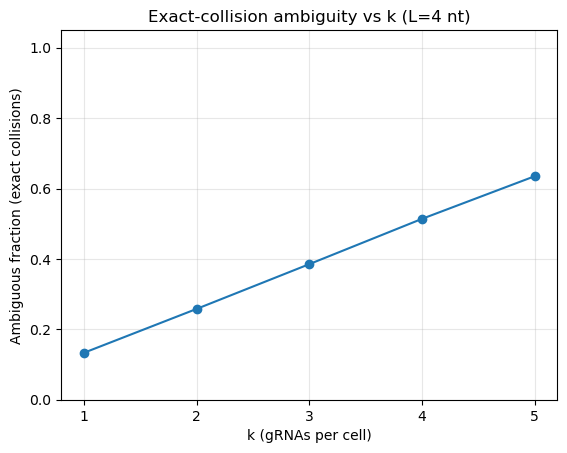

L=20, k=1: total=30, unique=30, ambig_frac=0.0000, max_group=1, collision_groups=0
L=20, k=2: total=465, unique=465, ambig_frac=0.0000, max_group=1, collision_groups=0
L=20, k=3: total=4960, unique=4960, ambig_frac=0.0000, max_group=1, collision_groups=0
L=20, k=4: total=40920, unique=40920, ambig_frac=0.0000, max_group=1, collision_groups=0
L=20, k=5: total=278256, unique=278256, ambig_frac=0.0000, max_group=1, collision_groups=0


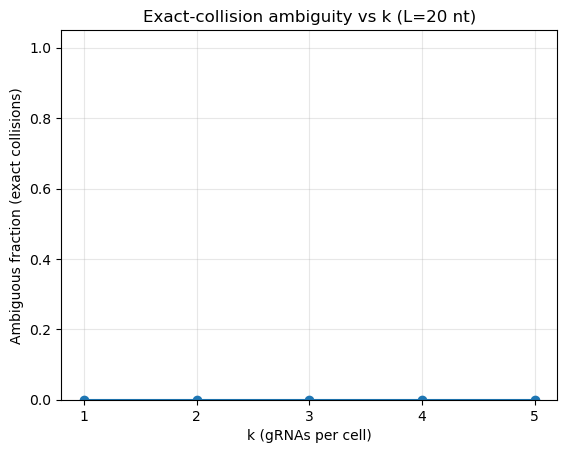

In [4]:
# Collision scaling for k = 1..5 (exact enumeration), for a given prefix length L
# Assumes you already have `spacers` = List[str] of DNA (A/C/G/T), length >= L.

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement
from collections import defaultdict

BASES = "ACGT"
B2I = {b:i for i,b in enumerate(BASES)}

def onehot_4color(seq: str, L: int) -> np.ndarray:
    x = np.zeros((L, 4), dtype=np.uint8)
    for p, b in enumerate(seq[:L]):
        x[p, B2I[b]] = 1
    return x

def k_sum_signal(spacers, combo, L: int) -> np.ndarray:
    # combo is a tuple of indices (length k), nondecreasing
    s = np.zeros((L, 4), dtype=np.uint8)
    for idx in combo:
        s += onehot_4color(spacers[idx], L)
    return s  # values in {0..k}

def sig_key(sig: np.ndarray):
    return sig.tobytes()  # fast exact hash key

def collision_stats_k(spacers, k: int, L: int):
    n = len(spacers)
    combos = combinations_with_replacement(range(n), k)
    mapping = defaultdict(int)  # key -> count
    total = 0
    for combo in combos:
        key = sig_key(k_sum_signal(spacers, combo, L))
        mapping[key] += 1
        total += 1
    unique = len(mapping)
    # "ambiguous combos" = combos whose key is shared by >=2 combos
    ambiguous = sum(cnt for cnt in mapping.values() if cnt >= 2)
    return {
        "k": k,
        "L": L,
        "total": total,
        "unique": unique,
        "ambiguous": ambiguous,
        "ambiguous_fraction": ambiguous / total,
        "max_group_size": max(mapping.values()),
        "n_collision_groups": sum(1 for cnt in mapping.values() if cnt >= 2),
    }

def run_k_1_to_5(spacers, L: int):
    stats = [collision_stats_k(spacers, k, L) for k in range(1, 6)]
    for s in stats:
        print(f"L={L:2d}, k={s['k']}: total={s['total']}, unique={s['unique']}, "
              f"ambig_frac={s['ambiguous_fraction']:.4f}, "
              f"max_group={s['max_group_size']}, collision_groups={s['n_collision_groups']}")
    return stats

def plot_ambig_vs_k(stats, title=None):
    ks = [s["k"] for s in stats]
    amb = [s["ambiguous_fraction"] for s in stats]
    plt.figure()
    plt.plot(ks, amb, marker="o")
    plt.xticks(ks)
    plt.xlabel("k (gRNAs per cell)")
    plt.ylabel("Ambiguous fraction (exact collisions)")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.title(title or f"Collision scaling (L={stats[0]['L']} nt)")
    plt.show()

# ---- RUN (choose L) ----
# Example: do it for L=10 and L=20
stats10 = run_k_1_to_5(spacers, L=4)
plot_ambig_vs_k(stats10, title="Exact-collision ambiguity vs k (L=4 nt)")

stats20 = run_k_1_to_5(spacers, L=20)
plot_ambig_vs_k(stats20, title="Exact-collision ambiguity vs k (L=20 nt)")


In [5]:
def plot_ambig_vs_k_many_L(spacers, ks=range(1,6), Ls=(3,4,5,6,10,20)):
    import matplotlib.pyplot as plt
    plt.figure()
    for L in Ls:
        amb = [collision_stats_k(spacers, k, L)["ambiguous_fraction"] for k in ks]
        plt.plot(list(ks), amb, marker="o", label=f"L={L}")
    plt.xticks(list(ks))
    plt.xlabel("k (gRNAs per cell)")
    plt.ylabel("Ambiguous fraction (exact collisions)")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.title("Exact-collision ambiguity vs k for different barcode lengths")
    plt.legend()
    plt.show()


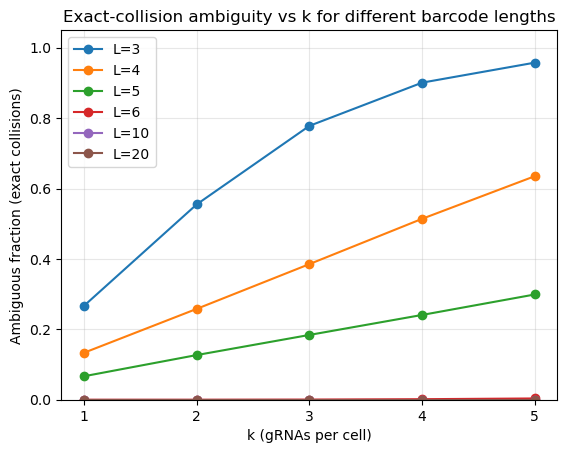

In [6]:
plot_ambig_vs_k_many_L(spacers)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

BASES = "ACGT"
B2I = {b:i for i,b in enumerate(BASES)}

def onehot_4color(seq: str, L: int) -> np.ndarray:
    x = np.zeros((L, 4), dtype=np.uint8)
    for p, b in enumerate(seq[:L]):
        x[p, B2I[b]] = 1
    return x

def pair_sum_signal(spacers, i: int, j: int, L: int) -> np.ndarray:
    return onehot_4color(spacers[i], L).astype(np.int16) + onehot_4color(spacers[j], L).astype(np.int16)

def hamming_distance_prefix(a: str, b: str, L: int) -> int:
    return sum(ca != cb for ca, cb in zip(a[:L], b[:L]))

def visualize_pairs_by_within_similarity_no_self(
    spacers,
    prefix_len: int = 10,
    n_show: int = 10,
    output_path: str = "../outputs/most_similar_nonself_pairs.png"
):
    """
    Plot pair-sum heatmaps for the non-self pairs (i<j) whose spacers are most similar
    (smallest Hamming distance over the first prefix_len bases).
    """
    n = len(spacers)
    pairs = list(combinations(range(n), 2))  # <-- no self-pairs

    scored = []
    for i, j in pairs:
        d = hamming_distance_prefix(spacers[i], spacers[j], prefix_len)
        scored.append((d, i, j))
    scored.sort(key=lambda x: x[0])

    top = scored[:n_show]

    cols = 5
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axes = np.array(axes).reshape(-1)

    for ax_idx, (d, i, j) in enumerate(top):
        sig = pair_sum_signal(spacers, i, j, prefix_len)
        matches = prefix_len - d
        ax = axes[ax_idx]
        ax.imshow(sig.T, aspect="auto", vmin=0, vmax=2)
        ax.set_yticks([0,1,2,3])
        ax.set_yticklabels(list(BASES))
        ax.set_xticks([])
        ax.set_title(f"({i},{j}) ham={d}/{prefix_len}\nmatch={matches}", fontsize=8)

    for ax_idx in range(n_show, len(axes)):
        axes[ax_idx].axis("off")

    plt.suptitle(f"Most similar non-self gRNA pairs (within-pair) — L={prefix_len}", fontsize=12)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved: {output_path}")

# Usage:
visualize_pairs_by_within_similarity_no_self(spacers, prefix_len=10, n_show=10)

In [8]:
def plot_ambig_vs_L_many_k(spacers, Ls=(3,4,5,6,10,20), ks=range(1,6)):
    import matplotlib.pyplot as plt
    plt.figure()
    for k in ks:
        amb = [collision_stats_k(spacers, k, L)["ambiguous_fraction"] for L in Ls]
        plt.plot(list(Ls), amb, marker="o", label=f"k={k}")
    plt.xticks(list(Ls))
    plt.xlabel("L (barcode length, nt)")
    plt.ylabel("Ambiguous fraction (exact collisions)")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.title("Exact-collision ambiguity vs barcode length for different k")
    plt.legend()
    plt.show()


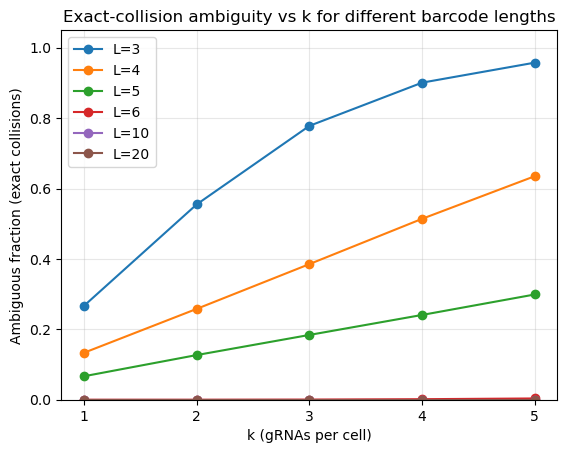

In [9]:
plot_ambig_vs_k_many_L(spacers)

In [34]:
def sanity_onehot(spacers, L=10, n_test=5):
    import numpy as np
    for idx in range(min(n_test, len(spacers))):
        X = onehot_4color(spacers[idx], L)        # (L,4)
        assert X.shape == (L,4)
        assert np.all(X.sum(axis=1) == 1), "each position must have exactly one 1"
        assert set(np.unique(X)).issubset({0,1}), "only 0/1 values"
    print("PASS: one-hot encoding checks")

sanity_onehot(spacers, L=10)


PASS: one-hot encoding checks


In [35]:
def sanity_ksum(spacers, k=6, L=7, n_trials=50):
    import numpy as np, random
    n = len(spacers)
    for _ in range(n_trials):
        combo = tuple(sorted([random.randrange(n) for _ in range(k)]))  # with replacement
        S = k_sum_signal(spacers, combo, L)  # (L,4)
        assert S.shape == (L,4)
        assert np.all(S.sum(axis=1) == k), "each position must sum to k"
        assert S.min() >= 0 and S.max() <= k, "counts must be between 0 and k"
        assert np.all(S.astype(int) == S), "should be integer counts"
    print("PASS: k-sum signal checks")

sanity_ksum(spacers, k=6, L=7)


PASS: k-sum signal checks


In [40]:
from collections import defaultdict
import random, numpy as np

def sample_collision_audit(spacers, k=6, L=7, n_samples=20000, seed=0):
    random.seed(seed)
    n = len(spacers)
    seen = defaultdict(list)

    for t in range(n_samples):
        combo = tuple(sorted([random.randrange(n) for _ in range(k)]))  # multiset
        sig = k_sum_signal(spacers, combo, L).tobytes()
        seen[sig].append(combo)

    # find any collision
    collisions = []
    for sig, combos in seen.items():
        uniq = list(dict.fromkeys(combos))  # preserve order, unique combos
        if len(uniq) >= 2:
            collisions.append((sig, uniq))

    print("sampled combos:", n_samples, "collision groups found:", len(collisions))
    if collisions:
        sig, combos = collisions[0]
        c1, c2 = combos[0], combos[1]
        S1 = k_sum_signal(spacers, c1, L)
        S2 = k_sum_signal(spacers, c2, L)
        print("example collision:", c1, c2, "equal?", np.array_equal(S1, S2))
        return c1, c2
    return None

sample_collision_audit(spacers, k=6, L=7, n_samples=20000)


sampled combos: 20000 collision groups found: 0


In [37]:
from collections import Counter

def k1_prefix_check(spacers, L):
    prefs = [s[:L] for s in spacers]
    c = Counter(prefs)
    # any prefix with count>1 produces collisions
    collision_groups = sum(1 for v in c.values() if v > 1)
    collided_items = sum(v for v in c.values() if v > 1)
    print("k=1: prefixes duplicated groups:", collision_groups, "collided guides:", collided_items)

k1_prefix_check(spacers, L=2)
k1_prefix_check(spacers, L=7)


k=1: prefixes duplicated groups: 10 collided guides: 28
k=1: prefixes duplicated groups: 0 collided guides: 0


In [38]:
def min_L_to_resolve(spacers, combo1, combo2, L_max=30):
    import numpy as np
    for L in range(1, L_max+1):
        if not np.array_equal(k_sum_signal(spacers, combo1, L),
                              k_sum_signal(spacers, combo2, L)):
            return L
    return None

combo1 = (0,0,6,25,28,29)
combo2 = (0,0,8,15,22,23)
print("min L to resolve:", min_L_to_resolve(spacers, combo1, combo2, L_max=30))


min L to resolve: 8


In [41]:
def min_L_for_ambig(spacers, k, Ls=range(1,21), thresh=1e-3):
    for L in Ls:
        af = collision_stats_k(spacers, k, L)["ambiguous_fraction"]
        if af <= thresh:
            return L, af
    return None, None

for k in range(2,7):
    Lstar, af = min_L_for_ambig(spacers, k, Ls=range(1,21), thresh=1e-3)
    print("k=", k, "min L for ambig<=0.1%:", Lstar, "ambig:", af)


k= 2 min L for ambig<=0.1%: 6 ambig: 0.0
k= 3 min L for ambig<=0.1%: 6 ambig: 0.0004032258064516129
k= 4 min L for ambig<=0.1%: 7 ambig: 4.887585532746823e-05
k= 5 min L for ambig<=0.1%: 7 ambig: 0.0002156287735035363
k= 6 min L for ambig<=0.1%: 7 ambig: 0.0005741886197294167
